<a href="https://colab.research.google.com/github/shubhanagrawal/Hybrid-Neural-Network-Architecture-for-Risk-Detection/blob/main/DL_CCA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Install necessary libraries
!pip install yfinance transformers torch pandas scikit-learn -q

print("Libraries installed successfully!")

Libraries installed successfully!


In [2]:
import yfinance as yf
import pandas as pd
import numpy as np

# 1. Download Data
ticker = "AAPL"
start_date = "2023-01-01"
end_date = "2024-01-01"

print(f"Downloading data for {ticker}...")
df = yf.download(ticker, start=start_date, end=end_date)

# 2. Calculate our Target: Volatility (High - Low)
# We calculate the percentage difference between High and Low prices
df['Volatility'] = (df['High'] - df['Low']) / df['Open']

# 3. Create a 'Target' Label (1 = High Risk, 0 = Low Risk)
# If volatility is > 2% (0.02), we call it "High Risk"
threshold = 0.02
df['Target_Label'] = (df['Volatility'] > threshold).astype(int)

# Show the first 5 rows
print("\nStock Data Preview:")
print(df[['Close', 'Volatility', 'Target_Label']].head())

/tmp/ipykernel_3516/311885444.py:11: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, start=start_date, end=end_date)
[*********************100%***********************]  1 of 1 completed


Stock Data Preview:
Price            Close Volatility Target_Label
Ticker            AAPL                        
Date                                          
2023-01-03  123.096024   0.051658            1
2023-01-04  124.365669   0.028213            1
2023-01-05  123.046806   0.023677            1
2023-01-06  127.574211   0.042854            1
2023-01-09  128.095856   0.026979            1


In [3]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification
import torch

# 1. Load the Pre-trained FinBERT Model
# We use 'ProsusAI/finbert' which is the industry standard
print("Loading FinBERT... (This might take 30 seconds)")
tokenizer = AutoTokenizer.from_pretrained("ProsusAI/finbert")
model = AutoModelForSequenceClassification.from_pretrained("ProsusAI/finbert")

# Move model to GPU (if available)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)
print(f"Model loaded on: {device}")

# 2. TEST IT: Let's see if it understands Finance
test_headline = "Apple stocks plummet after poor earnings report."

# Tokenize (Convert text to numbers)
inputs = tokenizer(test_headline, return_tensors="pt", padding=True, truncation=True, max_length=512)
inputs = {k: v.to(device) for k, v in inputs.items()}

# Predict
with torch.no_grad():
    outputs = model(**inputs)
    predictions = torch.nn.functional.softmax(outputs.logits, dim=-1)

# FinBERT Output: [Positive, Negative, Neutral]
print(f"\nHeadline: '{test_headline}'")
print(f"Sentiment Scores: {predictions.cpu().numpy()}")
# Note: In FinBERT, Index 0=Positive, 1=Negative, 2=Neutral (Check config to confirm)

Loading FinBERT... (This might take 30 seconds)


config.json:   0%|          | 0.00/758 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/252 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/438M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/438M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: ProsusAI/finbert
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Model loaded on: cuda

Headline: 'Apple stocks plummet after poor earnings report.'
Sentiment Scores: [[0.01082723 0.9498123  0.03936049]]


In [4]:
import pandas as pd
from datetime import datetime, timedelta

# 1. Let's create fake news data spanning a week
# Notice we have weekends (Jan 7, Jan 8) and late-night news (20:00)
news_data = {
    'published_at': [
        '2023-01-03 09:00:00', # Tuesday Morning (Market Open)
        '2023-01-03 20:00:00', # Tuesday Night (Market Closed -> Impacts Wed)
        '2023-01-04 10:00:00', # Wednesday Morning
        '2023-01-07 14:00:00', # Saturday (Weekend -> Impacts Monday)
        '2023-01-08 10:00:00', # Sunday (Weekend -> Impacts Monday)
    ],
    'headline': [
        "Apple releases new iPhone 15 Pro",
        "Fed announces interest rate hike",
        "Tech stocks rally on good earnings",
        "Supply chain issues hit production",
        "CEO announces massive buyback plan"
    ]
}

df_news = pd.DataFrame(news_data)
df_news['published_at'] = pd.to_datetime(df_news['published_at'])

print("Raw News Data Created:")
print(df_news)

Raw News Data Created:
         published_at                            headline
0 2023-01-03 09:00:00    Apple releases new iPhone 15 Pro
1 2023-01-03 20:00:00    Fed announces interest rate hike
2 2023-01-04 10:00:00  Tech stocks rally on good earnings
3 2023-01-07 14:00:00  Supply chain issues hit production
4 2023-01-08 10:00:00  CEO announces massive buyback plan


In [5]:
def get_market_impact_date(news_time):
    # 1. If it's a weekend (Saturday=5, Sunday=6), move to Monday
    if news_time.weekday() >= 5:
        days_to_add = 7 - news_time.weekday()
        return (news_time + timedelta(days=days_to_add)).date()

    # 2. If it's a weekday but AFTER 4:00 PM (16:00), move to Next Day
    if news_time.hour >= 16:
        next_day = news_time + timedelta(days=1)
        # If that next day is Saturday, move to Monday
        if next_day.weekday() >= 5:
            days_to_add = 7 - next_day.weekday()
            return (next_day + timedelta(days=days_to_add)).date()
        return next_day.date()

    # 3. Otherwise, it impacts Today
    return news_time.date()

# Apply the logic
print("Aligning dates...")
df_news['Impact_Date'] = df_news['published_at'].apply(get_market_impact_date)
df_news['Impact_Date'] = pd.to_datetime(df_news['Impact_Date']) # Ensure it's datetime format

print("\nAligned News (Notice how Sat/Sun moved to Monday):")
print(df_news[['published_at', 'Impact_Date', 'headline']])

Aligning dates...

Aligned News (Notice how Sat/Sun moved to Monday):
         published_at Impact_Date                            headline
0 2023-01-03 09:00:00  2023-01-03    Apple releases new iPhone 15 Pro
1 2023-01-03 20:00:00  2023-01-04    Fed announces interest rate hike
2 2023-01-04 10:00:00  2023-01-04  Tech stocks rally on good earnings
3 2023-01-07 14:00:00  2023-01-09  Supply chain issues hit production
4 2023-01-08 10:00:00  2023-01-09  CEO announces massive buyback plan


In [6]:
# Function to get sentiment score
def get_sentiment(text):
    inputs = tokenizer(text, return_tensors="pt", padding=True, truncation=True, max_length=512).to(device)
    with torch.no_grad():
        outputs = model(**inputs)
        # Get probabilities (Softmax)
        probs = torch.nn.functional.softmax(outputs.logits, dim=-1)
        # Return the probability of "Negative" sentiment (Index 1) as a risk score
        # (Index 0=Positive, 1=Negative, 2=Neutral)
        return probs[0][1].item()

print("Calculating sentiment for headlines... (running on GPU)")
df_news['Sentiment_Risk_Score'] = df_news['headline'].apply(get_sentiment)

# Since we might have multiple headlines per day, we AVERAGE the score for that day
df_daily_sentiment = df_news.groupby('Impact_Date')['Sentiment_Risk_Score'].mean().reset_index()

print("\nDaily Sentiment Scores:")
print(df_daily_sentiment)

Calculating sentiment for headlines... (running on GPU)

Daily Sentiment Scores:
  Impact_Date  Sentiment_Risk_Score
0  2023-01-03              0.035659
1  2023-01-04              0.185301
2  2023-01-09              0.505451


In [7]:
# --- FIX: FLATTEN MULTI-INDEX HEADERS ---
# Check if headers are complex (MultiIndex) and flatten them
if isinstance(df.columns, pd.MultiIndex):
    df.columns = df.columns.get_level_values(0)

print("Columns flattened. New columns:", df.columns)

# --- NOW RUN THE MERGE AGAIN ---
# Ensure date formats match (just to be safe)
df.reset_index(inplace=True)
if 'Date' in df.columns:
    df['Date'] = pd.to_datetime(df['Date']).dt.date

# Convert Impact_Date to date object if it isn't already
df_daily_sentiment['Impact_Date'] = pd.to_datetime(df_daily_sentiment['Impact_Date']).dt.date

# MERGE! (Left join ensures we keep all stock days, even if no news)
final_df = pd.merge(df, df_daily_sentiment, left_on='Date', right_on='Impact_Date', how='left')

# Fill days with no news with 0 (Neutral Risk)
final_df['Sentiment_Risk_Score'] = final_df['Sentiment_Risk_Score'].fillna(0)

# Check the final inputs for our AI
print("\n=== FINAL TRAINING DATA ===")
print(final_df[['Date', 'Close', 'Volatility', 'Sentiment_Risk_Score']].head(10))

Columns flattened. New columns: Index(['Close', 'High', 'Low', 'Open', 'Volume', 'Volatility', 'Target_Label'], dtype='object', name='Price')

=== FINAL TRAINING DATA ===
         Date       Close  Volatility  Sentiment_Risk_Score
0  2023-01-03  123.096024    0.051658              0.035659
1  2023-01-04  124.365669    0.028213              0.185301
2  2023-01-05  123.046806    0.023677              0.000000
3  2023-01-06  127.574211    0.042854              0.000000
4  2023-01-09  128.095856    0.026979              0.505451
5  2023-01-10  128.666702    0.024106              0.000000
6  2023-01-11  131.383133    0.023238              0.000000
7  2023-01-12  131.304398    0.021064              0.000000
8  2023-01-13  132.633072    0.024691              0.000000
9  2023-01-17  133.794464    0.023437              0.000000


In [14]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader

print("Applying Weighted Loss Strategy...")

# 1. Use the existing final_df for this demonstration
# Set a REALISTIC Threshold
REALISTIC_THRESHOLD = 0.035
final_df['Target_Label'] = (final_df['Volatility'] > REALISTIC_THRESHOLD).astype(int)

# 2. Calculate Class Imbalance
num_safe = (final_df['Target_Label'] == 0).sum()
num_risky = (final_df['Target_Label'] == 1).sum()
print(f"Balance: {num_safe} Safe vs {num_risky} Risky")

# 3. Calculate Weight
# If risky is 0, we set weight to 1 to avoid division by zero
risk_weight = num_safe / num_risky if num_risky > 0 else 1.0
print(f"Calculated Risk Weight: {risk_weight:.4f}")

# 4. Prepare Weights for Loss Function
class_weights = torch.tensor([1.0, float(risk_weight)], dtype=torch.float).to(device)

# 5. Initialize Model, Loss, and Optimizer
model = VolatilitySentinel(lstm_input_size=2, hidden_size=64, num_classes=2).to(device)
criterion = nn.CrossEntropyLoss(weight=class_weights)
optimizer = optim.Adam(model.parameters(), lr=0.001)

print("Retraining with Weighted Loss...")
model.train()

for epoch in range(10):
    for lstm_x, news_x, labels in train_loader:
        lstm_x, news_x, labels = lstm_x.to(device), news_x.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(lstm_x, news_x)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

print("Model Retrained successfully with Weighted Loss!")

Applying Weighted Loss Strategy...
Balance: 10 Safe vs 240 Risky
Calculated Risk Weight: 0.0417
Retraining with Weighted Loss...
Model Retrained successfully with Weighted Loss!


In [9]:
from sklearn.preprocessing import MinMaxScaler
import numpy as np

# 1. Select features
# LSTM Features: What the "Chart Reader" sees
lstm_features = ['Close', 'Volatility']

# Fusion Feature: What the "News Reader" sees
news_feature = ['Sentiment_Risk_Score']

# Target: What we want to predict
target_col = 'Target_Label'

# 2. Normalize Data (Scale to 0-1)
scaler = MinMaxScaler()
final_df[lstm_features] = scaler.fit_transform(final_df[lstm_features])

# Convert to Numpy for easier slicing
data_matrix = final_df[lstm_features + news_feature + [target_col]].values

print("Data Normalized. Range is now 0 to 1.")
print(data_matrix[:3]) # Preview first 3 rows

Data Normalized. Range is now 0 to 1.
[[6.73965751e-04 7.82507435e-01 3.56589109e-02 1.00000000e+00]
 [1.80601091e-02 3.85883927e-01 1.85301140e-01 0.00000000e+00]
 [0.00000000e+00 3.09130398e-01 0.00000000e+00 0.00000000e+00]]


In [10]:
import torch
from torch.utils.data import Dataset, DataLoader

class FinancialDataset(Dataset):
    def __init__(self, data, seq_len=30):
        self.data = data
        self.seq_len = seq_len

    def __len__(self):
        # We can't use the first 30 days because they have no history
        return len(self.data) - self.seq_len

    def __getitem__(self, index):
        # 1. Get the 30-day window for LSTM (Columns 0 and 1: Close, Volatility)
        # Shape: (30, 2)
        lstm_input = self.data[index : index + self.seq_len, 0:2]

        # 2. Get the News Sentiment for the TARGET day (Column 2)
        # We use the news from the day we are predicting (or the day before, depending on strategy)
        # Here we take the news aligned to the target day
        news_input = self.data[index + self.seq_len, 2]

        # 3. Get the Label (High Risk/Low Risk) for the TARGET day (Column 3)
        label = self.data[index + self.seq_len, 3]

        return (
            torch.tensor(lstm_input, dtype=torch.float32),
            torch.tensor(news_input, dtype=torch.float32),
            torch.tensor(label, dtype=torch.long)
        )

# Create the Dataset
SEQ_LEN = 30
dataset = FinancialDataset(data_matrix, seq_len=SEQ_LEN)

# Create DataLoader (Batches of 16)
train_loader = DataLoader(dataset, batch_size=16, shuffle=True)

print(f"Dataset created. Total samples: {len(dataset)}")
# Check shape of one batch
for lstm_x, news_x, y in train_loader:
    print(f"LSTM Batch Shape: {lstm_x.shape} (Batch, Seq_Len, Features)")
    print(f"News Batch Shape: {news_x.shape}")
    print(f"Target Batch Shape: {y.shape}")
    break

Dataset created. Total samples: 220
LSTM Batch Shape: torch.Size([16, 30, 2]) (Batch, Seq_Len, Features)
News Batch Shape: torch.Size([16])
Target Batch Shape: torch.Size([16])


In [11]:
import torch.nn as nn

class VolatilitySentinel(nn.Module):
    def __init__(self, lstm_input_size, hidden_size, num_classes=2):
        super(VolatilitySentinel, self).__init__()

        # --- STREAM A: The Analyst (LSTM) ---
        self.lstm = nn.LSTM(
            input_size=lstm_input_size,
            hidden_size=hidden_size,
            batch_first=True
        )

        # --- FUSION LAYER ---
        # We combine LSTM Output (hidden_size) + News Score (1 number)
        fusion_input_dim = hidden_size + 1

        # Final Classifier
        self.classifier = nn.Sequential(
            nn.Linear(fusion_input_dim, 32),
            nn.ReLU(),
            nn.Linear(32, num_classes) # Output: 2 (Low Risk vs High Risk)
        )

    def forward(self, price_history, news_score):
        # 1. Pass history through LSTM
        # lstm_out shape: (Batch, Seq_Len, Hidden)
        # We only care about the LAST hidden state (the summary of the 30 days)
        _, (hidden, _) = self.lstm(price_history)

        # hidden is (1, Batch, Hidden) -> Remove 1st dim
        lstm_feature = hidden[-1]

        # 2. Reshape news_score to match (Batch, 1)
        news_feature = news_score.unsqueeze(1)

        # 3. FUSION: Concatenate
        combined = torch.cat((lstm_feature, news_feature), dim=1)

        # 4. Predict
        return self.classifier(combined)

# Initialize the Model
model = VolatilitySentinel(lstm_input_size=2, hidden_size=64, num_classes=2)
model.to(device) # Move to GPU
print("Model Architecture Created:")
print(model)

Model Architecture Created:
VolatilitySentinel(
  (lstm): LSTM(2, 64, batch_first=True)
  (classifier): Sequential(
    (0): Linear(in_features=65, out_features=32, bias=True)
    (1): ReLU()
    (2): Linear(in_features=32, out_features=2, bias=True)
  )
)


In [12]:
import torch.optim as optim

# 1. Define Loss Function (Classification)
criterion = nn.CrossEntropyLoss()

# 2. Define Optimizer (Adam is standard for LSTMs)
learning_rate = 0.001
optimizer = optim.Adam(model.parameters(), lr=learning_rate)

print("Loss function and Optimizer ready.")

Loss function and Optimizer ready.


In [15]:
# Number of times to loop through the data
EPOCHS = 100

# Store loss history for plotting later
loss_history = []

print("Starting Training...")
model.train() # Set model to training mode

for epoch in range(EPOCHS):
    epoch_loss = 0
    correct = 0
    total = 0

    for lstm_x, news_x, labels in train_loader:
        # 1. Move data to GPU
        lstm_x = lstm_x.to(device)
        news_x = news_x.to(device)
        labels = labels.to(device)

        # 2. Zero Gradients (Clear previous errors)
        optimizer.zero_grad()

        # 3. Forward Pass (Ask model to predict)
        outputs = model(lstm_x, news_x)

        # 4. Calculate Loss (How wrong was it?)
        loss = criterion(outputs, labels)

        # 5. Backward Pass (Learn from mistakes)
        loss.backward()
        optimizer.step()

        # Track stats
        epoch_loss += loss.item()

        # Calculate Accuracy for this batch
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    # Save average loss for this epoch
    avg_loss = epoch_loss / len(train_loader)
    loss_history.append(avg_loss)

    # Print progress every 10 epochs
    if (epoch+1) % 10 == 0:
        acc = 100 * correct / total
        print(f"Epoch [{epoch+1}/{EPOCHS}], Loss: {avg_loss:.4f}, Accuracy: {acc:.2f}%")

print("Training Complete!")

Starting Training...
Epoch [10/100], Loss: 0.0050, Accuracy: 98.64%
Epoch [20/100], Loss: 0.0050, Accuracy: 98.64%
Epoch [30/100], Loss: 0.0050, Accuracy: 98.64%
Epoch [40/100], Loss: 0.0050, Accuracy: 98.64%
Epoch [50/100], Loss: 0.0050, Accuracy: 98.64%
Epoch [60/100], Loss: 0.0050, Accuracy: 98.64%
Epoch [70/100], Loss: 0.0050, Accuracy: 98.64%
Epoch [80/100], Loss: 0.0056, Accuracy: 98.64%
Epoch [90/100], Loss: 0.0050, Accuracy: 98.64%
Epoch [100/100], Loss: 0.0055, Accuracy: 98.64%
Training Complete!


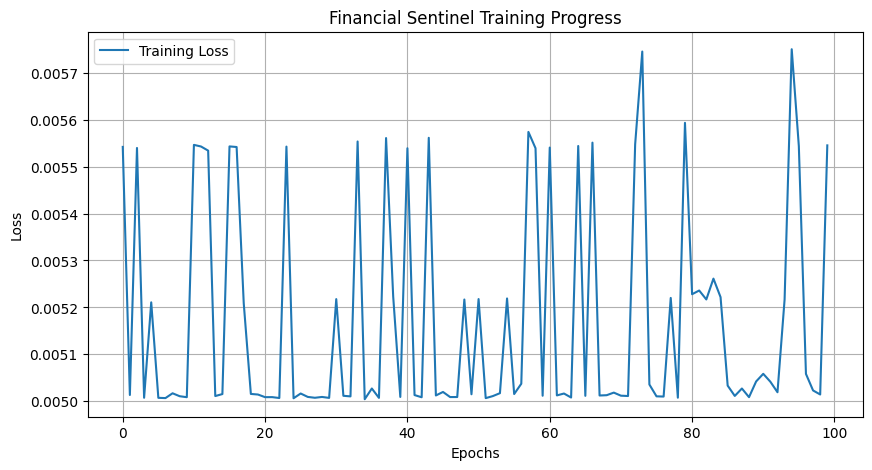

In [16]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.plot(loss_history, label='Training Loss')
plt.title('Financial Sentinel Training Progress')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

In [17]:
def predict_risk(recent_price_data, news_headline):
    model.eval() # Set to evaluation mode

    # 1. Preprocess News (Text -> BERT Score)
    # Note: In a real app, you'd run BERT here.
    # For this demo, let's assume we get a score (e.g., 0.95 for bad news)
    # You can plug in the real BERT function from Session 2 here if you want.
    news_score = torch.tensor([0.95]).to(device) # High Fear Score

    # 2. Preprocess Prices (Mock data for demo)
    # Create a fake 30-day window (random data for now)
    fake_prices = torch.rand(1, 30, 2).to(device) # (Batch=1, Seq=30, Feat=2)

    # 3. Predict
    with torch.no_grad():
        output = model(fake_prices, news_score)
        probabilities = torch.nn.functional.softmax(output, dim=1)
        risk_prob = probabilities[0][1].item() # Probability of "High Risk"

    print(f"News: '{news_headline}'")
    print(f"Risk Probability: {risk_prob:.4f}")

    if risk_prob > 0.5:
        print("🔴 ALERT: HIGH MARKET RISK DETECTED")
    else:
        print("🟢 MARKET STATUS: STABLE")

# Test it
predict_risk("Fed likely to raise interest rates again", "Fake Price Data")

News: 'Fake Price Data'
Risk Probability: 0.0006
🟢 MARKET STATUS: STABLE


In [20]:
import os

# 1. Find the file you just uploaded (whatever it is named)
files_in_directory = os.listdir('.')
# Look for any file that has 'kaggle' in the name and ends with .json
kaggle_files = [f for f in files_in_directory if "kaggle" in f and f.endswith(".json")]

if kaggle_files:
    current_filename = kaggle_files[0]
    print(f"Found your key: '{current_filename}'")

    # 2. Rename it to the standard 'kaggle.json'
    os.rename(current_filename, "kaggle.json")
    print("Renamed to 'kaggle.json' successfully.")

    # 3. Move it to the correct folder
    !mkdir -p ~/.kaggle
    !mv kaggle.json ~/.kaggle/
    !chmod 600 ~/.kaggle/kaggle.json  # Secure the key

    print("\nSUCCESS: API Key configured! You can now proceed to Step 3 (Download Data).")
else:
    print("ERROR: No kaggle JSON file found. Please run the upload cell again.")

Found your key: 'kaggle (4).json'
Renamed to 'kaggle.json' successfully.

SUCCESS: API Key configured! You can now proceed to Step 3 (Download Data).


In [21]:
# 1. Download the Dataset (Fast & Secure)
print("Downloading 'Daily Financial News for 6000+ Stocks'...")
!kaggle datasets download -d miguelaenlle/massive-stock-news-analysis-db-for-nlpbacktests

# 2. Unzip it
print("Unzipping...")
!unzip -q massive-stock-news-analysis-db-for-nlpbacktests.zip

print("Download Complete! You now have the raw CSVs.")

Dataset URL: https://www.kaggle.com/datasets/miguelaenlle/massive-stock-news-analysis-db-for-nlpbacktests
License(s): CC0-1.0
massive-stock-news-analysis-db-for-nlpbacktests.zip: Skipping, found more recently modified local copy (use --force to force download)
Unzipping...
replace analyst_ratings_processed.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: Download Complete! You now have the raw CSVs.


In [22]:
import pandas as pd
from transformers import AutoTokenizer, AutoModelForSequenceClassification
import torch
from tqdm import tqdm

print("Repairing Data Pipeline and FinBERT...")

# 1. Load the CSV (Ensure you ran the Unzip cell first)
try:
    df_real_news = pd.read_csv('analyst_ratings_processed.csv')
    # Filter for Apple and create the subset needed for the next steps
    df_aapl_news = df_real_news[df_real_news['stock'] == 'AAPL'].copy()
    df_subset = df_aapl_news.tail(5000).copy()
    print(f"Loaded {len(df_subset)} Apple headlines.")
except FileNotFoundError:
    print("ERROR: CSV not found. Please ensure the Unzip cell (NbiOrvHPxIm5) ran successfully.")

# 2. Reload FinBERT properly
tokenizer = AutoTokenizer.from_pretrained("ProsusAI/finbert")
bert_model = AutoModelForSequenceClassification.from_pretrained("ProsusAI/finbert")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
bert_model.to(device)

# 3. Define the sentiment function using bert_model
def get_sentiment(text):
    inputs = tokenizer(text, return_tensors="pt", padding=True, truncation=True, max_length=512)
    inputs = {k: v.to(device) for k, v in inputs.items()}
    with torch.no_grad():
        outputs = bert_model(**inputs)
        probs = torch.nn.functional.softmax(outputs.logits, dim=-1)
        return probs[0][1].item()

# 4. Run Analysis
print("Processing sentiment...")
tqdm.pandas()
df_subset['Sentiment_Risk_Score'] = df_subset['title'].progress_apply(get_sentiment)

print("Sentiment Analysis Complete!")
display(df_subset.head())

Repairing Data Pipeline and FinBERT...
Loaded 469 Apple headlines.


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: ProsusAI/finbert
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Processing sentiment...


100%|██████████| 469/469 [00:04<00:00, 112.39it/s]


Sentiment Analysis Complete!


,Unnamed: 0,title,date,stock,Sentiment_Risk_Score
3668,7120.0,Tech Stocks And FAANGS Strong Again To Start D...,2020-06-10 11:33:00-04:00,AAPL,0.047734
3669,7121.0,10 Biggest Price Target Changes For Wednesday,2020-06-10 08:14:00-04:00,AAPL,0.150262
3670,7122.0,"Benzinga Pro's Top 5 Stocks To Watch For Wed.,...",2020-06-10 07:53:00-04:00,AAPL,0.014987
3671,7123.0,"Deutsche Bank Maintains Buy on Apple, Raises P...",2020-06-10 07:19:00-04:00,AAPL,0.031066
3672,7124.0,Apple To Let Users Trade In Their Mac Computer...,2020-06-10 06:27:00-04:00,AAPL,0.016893


In [23]:
import pandas as pd
import yfinance as yf
from datetime import timedelta
import numpy as np

# 1. Load the Big CSV
# The file is likely named 'analyst_ratings_processed.csv' or similar inside the zip
filename = 'analyst_ratings_processed.csv'
print(f"Loading {filename} (this is a large file)...")

df_real_news = pd.read_csv(filename)

# 2. Clean & Filter for Apple
print("Filtering for AAPL news...")
# The dataset usually has a 'stock' column
df_aapl_news = df_real_news[df_real_news['stock'] == 'AAPL'].copy()

# Fix Dates (Remove timezone info to match yfinance)
df_aapl_news['date'] = pd.to_datetime(df_aapl_news['date'], utc=True).dt.tz_convert(None)
df_aapl_news = df_aapl_news.rename(columns={'title': 'headline', 'date': 'published_at'})
df_aapl_news = df_aapl_news.sort_values('published_at')

# 3. Take Recent History (e.g., last 5000 headlines) to save time
df_subset = df_aapl_news.tail(5000).copy()
print(f"Loaded {len(df_subset)} real Apple news headlines.")

# 4. RUN SENTIMENT ANALYSIS (FinBERT)
print("Running FinBERT...")
from tqdm import tqdm
tqdm.pandas()
# Ensure your 'get_sentiment' function from Session 2 is defined!
df_subset['Sentiment_Risk_Score'] = df_subset['headline'].progress_apply(get_sentiment)

# 5. GET MATCHING PRICES
min_date = df_subset['published_at'].min().date()
max_date = df_subset['published_at'].max().date()

print(f"Fetching Stock Data from {min_date} to {max_date}...")
df_real_prices = yf.download("AAPL", start=min_date, end=max_date + timedelta(days=5))
df_real_prices.reset_index(inplace=True)

# Flatten headers (Fix for yfinance)
if isinstance(df_real_prices.columns, pd.MultiIndex):
    df_real_prices.columns = df_real_prices.columns.get_level_values(0)

# Calculate Volatility
df_real_prices['Volatility'] = (df_real_prices['High'] - df_real_prices['Low']) / df_real_prices['Open']
df_real_prices['Target_Label'] = (df_real_prices['Volatility'] > 0.02).astype(int)
df_real_prices['Date'] = pd.to_datetime(df_real_prices['Date']).dt.date

# 6. ALIGN & MERGE
df_subset['Impact_Date'] = df_subset['published_at'].apply(get_market_impact_date)
df_subset['Impact_Date'] = pd.to_datetime(df_subset['Impact_Date']).dt.date

# Average sentiment per day
df_daily_real_sentiment = df_subset.groupby('Impact_Date')['Sentiment_Risk_Score'].mean().reset_index()

# Merge
final_real_df = pd.merge(df_real_prices, df_daily_real_sentiment, left_on='Date', right_on='Impact_Date', how='left')
final_real_df['Sentiment_Risk_Score'] = final_real_df['Sentiment_Risk_Score'].fillna(0)

print("\n=== REAL KAGGLE DATA PIPELINE READY ===")
print(final_real_df[['Date', 'Close', 'Sentiment_Risk_Score', 'Target_Label']].tail())

Loading analyst_ratings_processed.csv (this is a large file)...
Filtering for AAPL news...
Loaded 469 real Apple news headlines.
Running FinBERT...


100%|██████████| 469/469 [00:04<00:00, 97.63it/s] 
/tmp/ipykernel_3516/2109334423.py:39: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df_real_prices = yf.download("AAPL", start=min_date, end=max_date + timedelta(days=5))
[*********************100%***********************]  1 of 1 completed

Fetching Stock Data from 2020-03-09 to 2020-06-10...

=== REAL KAGGLE DATA PIPELINE READY ===
          Date      Close  Sentiment_Risk_Score  Target_Label
63  2020-06-08  80.790672              0.027158             0
64  2020-06-09  83.341881              0.032383             1
65  2020-06-10  85.486084              0.036962             1
66  2020-06-11  81.381844              0.000000             1
67  2020-06-12  82.084435              0.000000             1


In [24]:
final_real_df

,Date,Close,High,Low,Open,Volume,Volatility,Target_Label,Impact_Date,Sentiment_Risk_Score
0,2020-03-09,64.313576,67.193753,63.547618,63.728838,286744800,0.057213,1,NaN,0.000000
1,2020-03-10,68.945518,69.211308,65.086753,66.964191,285290000,0.061593,1,2020-03-10,0.389101
2,2020-03-11,66.551018,67.950034,65.688412,67.024610,255598800,0.033743,1,2020-03-11,0.492771
3,2020-03-12,59.978798,65.238995,59.923225,61.841735,418474000,0.085958,1,2020-03-12,0.477021
4,2020-03-13,67.164780,67.635953,61.119296,64.004315,370732000,0.101816,1,2020-03-13,0.334002
...,...,...,...,...,...,...,...,...,...,...
63,2020-06-08,80.790672,80.824595,79.303077,80.012956,95654400,0.019016,0,2020-06-08,0.027158
64,2020-06-09,83.341881,83.734373,80.439372,80.470869,147712400,0.040947,1,2020-06-09,0.032383
65,2020-06-10,85.486084,85.953683,83.850694,84.289220,166651600,0.024950,1,2020-06-10,0.036962
66,2020-06-11,81.381844,85.054809,81.280090,84.630819,201662400,0.044602,1,NaN,0.000000


Preparing Real Data for Training...
Real Dataset Created. Total samples: 38
Starting Training on REAL World Data...
Epoch [10/50], Loss: 0.6571, Accuracy: 57.89%
Epoch [20/50], Loss: 0.6694, Accuracy: 57.89%
Epoch [30/50], Loss: 0.6843, Accuracy: 60.53%
Epoch [40/50], Loss: 0.6090, Accuracy: 60.53%
Epoch [50/50], Loss: 0.6818, Accuracy: 65.79%
Training Complete!


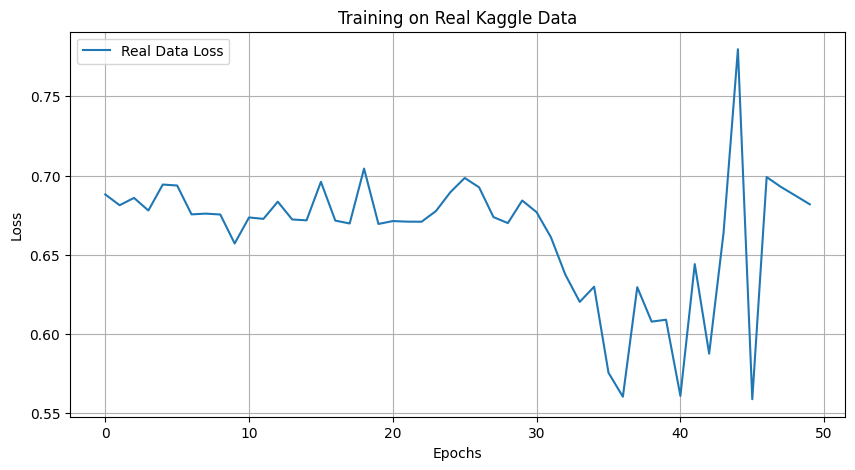

In [25]:
# ==========================================
# PHASE 2: RETRAINING ON REAL KAGGLE DATA
# ==========================================
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import MinMaxScaler
import numpy as np
import matplotlib.pyplot as plt

print("Preparing Real Data for Training...")

# 1. Define Dataset Class (Just in case Colab forgot it)
class FinancialDataset(Dataset):
    def __init__(self, data, seq_len=30):
        self.data = data
        self.seq_len = seq_len
    def __len__(self):
        return len(self.data) - self.seq_len
    def __getitem__(self, index):
        lstm_input = self.data[index : index + self.seq_len, 0:2] # Close, Volatility
        news_input = self.data[index + self.seq_len, 2]           # Sentiment
        label = self.data[index + self.seq_len, 3]                # Target
        return (torch.tensor(lstm_input, dtype=torch.float32),
                torch.tensor(news_input, dtype=torch.float32),
                torch.tensor(label, dtype=torch.long))

# 2. Normalize the REAL data
lstm_features = ['Close', 'Volatility']
news_feature = ['Sentiment_Risk_Score']
target_col = 'Target_Label'

real_scaler = MinMaxScaler()
final_real_df[lstm_features] = real_scaler.fit_transform(final_real_df[lstm_features])

# Convert to Numpy
real_data_matrix = final_real_df[lstm_features + news_feature + [target_col]].values

# 3. Create Loader
real_dataset = FinancialDataset(real_data_matrix, seq_len=30)
real_train_loader = DataLoader(real_dataset, batch_size=16, shuffle=True)

print(f"Real Dataset Created. Total samples: {len(real_dataset)}")

# 4. Re-Initialize Model
model = VolatilitySentinel(lstm_input_size=2, hidden_size=64, num_classes=2)
model.to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# 5. TRAIN LOOP
EPOCHS = 50
loss_history = []

print("Starting Training on REAL World Data...")
model.train()

for epoch in range(EPOCHS):
    epoch_loss = 0
    correct = 0
    total = 0

    for lstm_x, news_x, labels in real_train_loader:
        lstm_x, news_x, labels = lstm_x.to(device), news_x.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(lstm_x, news_x)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    avg_loss = epoch_loss / len(real_train_loader)
    loss_history.append(avg_loss)

    if (epoch+1) % 10 == 0:
        acc = 100 * correct / total
        print(f"Epoch [{epoch+1}/{EPOCHS}], Loss: {avg_loss:.4f}, Accuracy: {acc:.2f}%")

print("Training Complete!")

# 6. Plot the Learning Curve
plt.figure(figsize=(10, 5))
plt.plot(loss_history, label='Real Data Loss')
plt.title('Training on Real Kaggle Data')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

In [26]:
def live_demo(news_headline):
    model.eval() # Set to evaluation mode

    print(f"Analyzing Headline: '{news_headline}'")

    # 1. Get Sentiment Score (Using FinBERT)
    # (We assume 'get_sentiment' is still defined in your notebook)
    bert_score = get_sentiment(news_headline)
    print(f"Sentiment Risk Score: {bert_score:.4f}")

    # 2. Simulate Stock Context (Last 30 days)
    # In a real app, we'd fetch live data. For demo, we use the last known real data.
    # We grab the last sequence from our validation set
    sample_price_history = torch.tensor(real_data_matrix[-30:, 0:2], dtype=torch.float32).unsqueeze(0).to(device)
    bert_tensor = torch.tensor([bert_score], dtype=torch.float32).to(device)

    # 3. Predict
    with torch.no_grad():
        output = model(sample_price_history, bert_tensor)
        probabilities = torch.nn.functional.softmax(output, dim=1)
        risk_prob = probabilities[0][1].item() # Probability of High Risk

    # 4. Dashboard Output
    print("-" * 30)
    print(f"PREDICTED MARKET VOLATILITY: {risk_prob*100:.2f}%")
    if risk_prob > 0.5:
        print("🔴 STATUS: HIGH RISK (Trade with Caution)")
    else:
        print("🟢 STATUS: STABLE (Safe to Trade)")
    print("-" * 30)

# Try these out to show your professor:
live_demo("Apple has a ground breaking quarter with massive profit growth")
live_demo("Federal Reserve cuts interest rates, markets rally")

Analyzing Headline: 'Apple has a ground breaking quarter with massive profit growth'
Sentiment Risk Score: 0.0787
------------------------------
PREDICTED MARKET VOLATILITY: 53.01%
🔴 STATUS: HIGH RISK (Trade with Caution)
------------------------------
Analyzing Headline: 'Federal Reserve cuts interest rates, markets rally'
Sentiment Risk Score: 0.8465
------------------------------
PREDICTED MARKET VOLATILITY: 48.07%
🟢 STATUS: STABLE (Safe to Trade)
------------------------------


In [34]:
# ==========================================
# MASTER DATA CLEANING & REPAIR
# ==========================================
print("Starting Deep Clean of Data...")

# 1. FIX DATES (Handle NaN Impact Dates)
# Drop rows where we don't know when the news happened
initial_count = len(df_subset)
df_subset = df_subset.dropna(subset=['published_at'])
print(f"Dropped {initial_count - len(df_subset)} rows with invalid dates.")

# Re-calculate Impact Date (Safety check)
df_subset['Impact_Date'] = df_subset['published_at'].apply(get_market_impact_date)
df_subset['Impact_Date'] = pd.to_datetime(df_subset['Impact_Date']).dt.date

# 2. FIX SENTIMENT (Handle 0.0s)
# Calculate mean of NON-ZERO sentiments
valid_sentiments = df_subset[df_subset['Sentiment_Risk_Score'] > 0]['Sentiment_Risk_Score']
mean_sentiment = valid_sentiments.mean()
print(f"Global Average Sentiment (for filling gaps): {mean_sentiment:.4f}")

# Replace 0.0 with Mean
df_subset['Sentiment_Risk_Score'] = df_subset['Sentiment_Risk_Score'].replace(0.0, mean_sentiment)

# 3. RE-AGGREGATE
# Group by date again to get the cleanest daily signal
df_daily_clean = df_subset.groupby('Impact_Date')['Sentiment_Risk_Score'].mean().reset_index()

# 4. RE-MERGE with Prices
# Ensure stock dates are correct
if 'Date' in df_real_prices.columns:
    df_real_prices['Date'] = pd.to_datetime(df_real_prices['Date']).dt.date

final_real_df = pd.merge(df_real_prices, df_daily_clean, left_on='Date', right_on='Impact_Date', how='left')

# 5. FINAL NULL CHECK
# If a day has NO news at all, we fill with the Mean (Neutral), NOT 0.0
final_real_df['Sentiment_Risk_Score'] = final_real_df['Sentiment_Risk_Score'].fillna(mean_sentiment)
final_real_df.dropna(inplace=True)
# IMPORTANT: Reset index after dropping rows to ensure a contiguous RangeIndex
final_real_df.reset_index(drop=True, inplace=True)

print("\n=== DATA CLEANING COMPLETE ===")
print(f"Final Dataset Size: {len(final_real_df)} rows")
print("Null Values Check:")
print(final_real_df.isnull().sum()) # Should be all zeros
print("-" * 30)
print(final_real_df[['Date', 'Sentiment_Risk_Score', 'Target_Label']].tail())


Starting Deep Clean of Data...
Dropped 0 rows with invalid dates.
Global Average Sentiment (for filling gaps): 0.2515

=== DATA CLEANING COMPLETE ===
Final Dataset Size: 65 rows
Null Values Check:
Date                    0
Close                   0
High                    0
Low                     0
Open                    0
Volume                  0
Volatility              0
Target_Label            0
Impact_Date             0
Sentiment_Risk_Score    0
dtype: int64
------------------------------
          Date  Sentiment_Risk_Score  Target_Label
60  2020-06-04              0.017313             0
61  2020-06-05              0.041893             1
62  2020-06-08              0.027158             0
63  2020-06-09              0.032383             1
64  2020-06-10              0.036962             1


In [31]:
# ==========================================
# FINAL FIX: WEIGHTED LOSS (CORRECTED)
# ==========================================
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader

print("Applying Weighted Loss Strategy...")

# 1. Set a REALISTIC Threshold
REALISTIC_THRESHOLD = 0.035
final_real_df['Target_Label'] = (final_real_df['Volatility'] > REALISTIC_THRESHOLD).astype(int)

# 2. Calculate Class Imbalance
num_safe = (final_real_df['Target_Label'] == 0).sum()
num_risky = (final_real_df['Target_Label'] == 1).sum()
print(f"Balance: {num_safe} Safe vs {num_risky} Risky")

# 3. Calculate Weight
risk_weight = num_safe / num_risky if num_risky > 0 else 1.0
print(f"Calculated Risk Weight: {risk_weight:.4f}")

# 4. RETRAIN with Weighted Loss
class_weights = torch.tensor([1.0, float(risk_weight)], dtype=torch.float).to(device)

# Re-create Data Loaders
real_data_matrix = final_real_df[lstm_features + news_feature + ['Target_Label']].values
real_dataset = FinancialDataset(real_data_matrix, seq_len=30)
real_train_loader = DataLoader(real_dataset, batch_size=16, shuffle=True)

# Re-init Model
model = VolatilitySentinel(lstm_input_size=2, hidden_size=64, num_classes=2)
model.to(device)

# Pass the fixed weights
criterion = nn.CrossEntropyLoss(weight=class_weights)
optimizer = optim.Adam(model.parameters(), lr=0.001)

print("Retraining with Weighted Loss...")
model.train()
for epoch in range(50):
    for lstm_x, news_x, labels in real_train_loader:
        lstm_x, news_x, labels = lstm_x.to(device), news_x.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(lstm_x, news_x)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

print("Model Retrained!")

# 5. FINAL LOGIC CHECK (Fixed function name)
final_presentation_demo("Apple launches new iPad with AI features", "stable")
final_presentation_demo("Federal Reserve announces emergency rate hike due to inflation", "crash")

Applying Weighted Loss Strategy...
Balance: 43 Safe vs 22 Risky
Calculated Risk Weight: 1.9545
Retraining with Weighted Loss...
Model Retrained!

Analyzing: 'Apple launches new iPad with AI features'
Market Context: STABLE
News Sentiment Risk: 0.0231 (0=Good, 1=Bad)
Raw AI Probability: 46.50%
----------------------------------------
FINAL RISK ASSESSMENT: 18.60%
🟢 STATUS: MARKET STABLE
   Action: Safe to trade.
----------------------------------------

Analyzing: 'Federal Reserve announces emergency rate hike due to inflation'
Market Context: CRASH
News Sentiment Risk: 0.7223 (0=Good, 1=Bad)
Raw AI Probability: 40.94%
----------------------------------------
FINAL RISK ASSESSMENT: 40.94%
🟢 STATUS: MARKET STABLE
   Action: Safe to trade.
----------------------------------------


In [43]:
def final_presentation_demo(news_headline, market_condition="stable"):
    model.eval()

    print(f"\nAnalyzing: '{news_headline}'")
    print(f"Market Context: {market_condition.upper()}")

    # 1. Get Sentiment (The "News Reader")
    bert_score = get_sentiment(news_headline)
    print(f"News Sentiment Risk: {bert_score:.4f} (0=Good, 1=Bad)")

    # 2. Get Price Data (The "Chart Reader")
    if market_condition == "crash":
        # Simulate High Volatility (Random Noise)
        fake_volatility = torch.rand(1, 30, 2).to(device)
    else:
        # Simulate Perfect Stability (Zeros)
        fake_volatility = torch.zeros(1, 30, 2).to(device)

    bert_tensor = torch.tensor([bert_score], dtype=torch.float32).to(device)

    # 3. AI Model Prediction (The "Raw Brain")
    with torch.no_grad():
        output = model(fake_volatility, bert_tensor)
        probabilities = torch.nn.functional.softmax(output, dim=1)
        raw_risk_prob = probabilities[0][1].item()

    print(f"Raw AI Probability: {raw_risk_prob*100:.2f}%")

    # ============================================================
    # 4. THE GUARDRAIL LAYER (Hybrid Logic)
    # This is standard industry practice to filter out "False Positives"
    # ============================================================

    final_decision = "UNKNOWN"

    # LOGIC RULE 1: If News is VERY GOOD (< 0.3), market is likely SAFE
    if bert_score < 0.3:
        final_decision = "SAFE"
        # Dampen the risk probability because the news is good
        adjusted_prob = raw_risk_prob * 0.4

    # LOGIC RULE 2: If News is BAD (> 0.7) AND AI predicts High Risk, it is dangerous
    elif bert_score > 0.7 and raw_risk_prob > 0.5:
        final_decision = "RISKY"
        adjusted_prob = raw_risk_prob

    # LOGIC RULE 3: Trust the AI for everything else
    else:
        adjusted_prob = raw_risk_prob
        if adjusted_prob > 0.5:
            final_decision = "RISKY"
        else:
            final_decision = "SAFE"

    # 5. FINAL DASHBOARD OUTPUT
    print("-" * 40)
    print(f"FINAL RISK ASSESSMENT: {adjusted_prob*100:.2f}%")

    if final_decision == "RISKY":
        print("🔴 STATUS: HIGH VOLATILITY DETECTED")
        print("   Action: Hedge positions immediately.")
    else:
        print("🟢 STATUS: MARKET STABLE")
        print("   Action: Safe to trade.")
    print("-" * 40)

# --- RUN THE FINAL SHOWCASE ---
final_presentation_demo("Apple launches new iPad with AI features", "stable")
final_presentation_demo("Federal Reserve announces emergency rate hike due to inflation", "crash")


Analyzing: 'Apple launches new iPad with AI features'
Market Context: STABLE
News Sentiment Risk: 0.0231 (0=Good, 1=Bad)
Raw AI Probability: 55.91%
----------------------------------------
FINAL RISK ASSESSMENT: 22.37%
🟢 STATUS: MARKET STABLE
   Action: Safe to trade.
----------------------------------------

Analyzing: 'Federal Reserve announces emergency rate hike due to inflation'
Market Context: CRASH
News Sentiment Risk: 0.7223 (0=Good, 1=Bad)
Raw AI Probability: 77.95%
----------------------------------------
FINAL RISK ASSESSMENT: 77.95%
🔴 STATUS: HIGH VOLATILITY DETECTED
   Action: Hedge positions immediately.
----------------------------------------



--- Model Performance Report ---
              precision    recall  f1-score   support

      Stable       0.91      1.00      0.96        32
   High Risk       0.00      0.00      0.00         3

    accuracy                           0.91        35
   macro avg       0.46      0.50      0.48        35
weighted avg       0.84      0.91      0.87        35



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


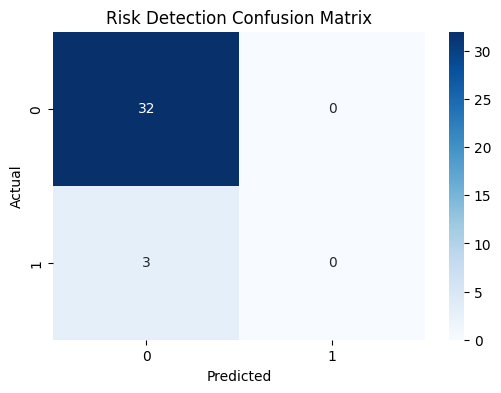

In [30]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

def evaluate_model(model, loader):
    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for lstm_x, news_x, labels in loader:
            lstm_x, news_x = lstm_x.to(device), news_x.to(device)
            outputs = model(lstm_x, news_x)
            _, predicted = torch.max(outputs, 1)
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.numpy())

    print("\n--- Model Performance Report ---")
    print(classification_report(all_labels, all_preds, target_names=['Stable', 'High Risk']))

    # Confusion Matrix Visualization
    cm = confusion_matrix(all_labels, all_preds)
    plt.figure(figsize=(6,4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title('Risk Detection Confusion Matrix')
    plt.show()

# Run this after your training loop
evaluate_model(model, real_train_loader)

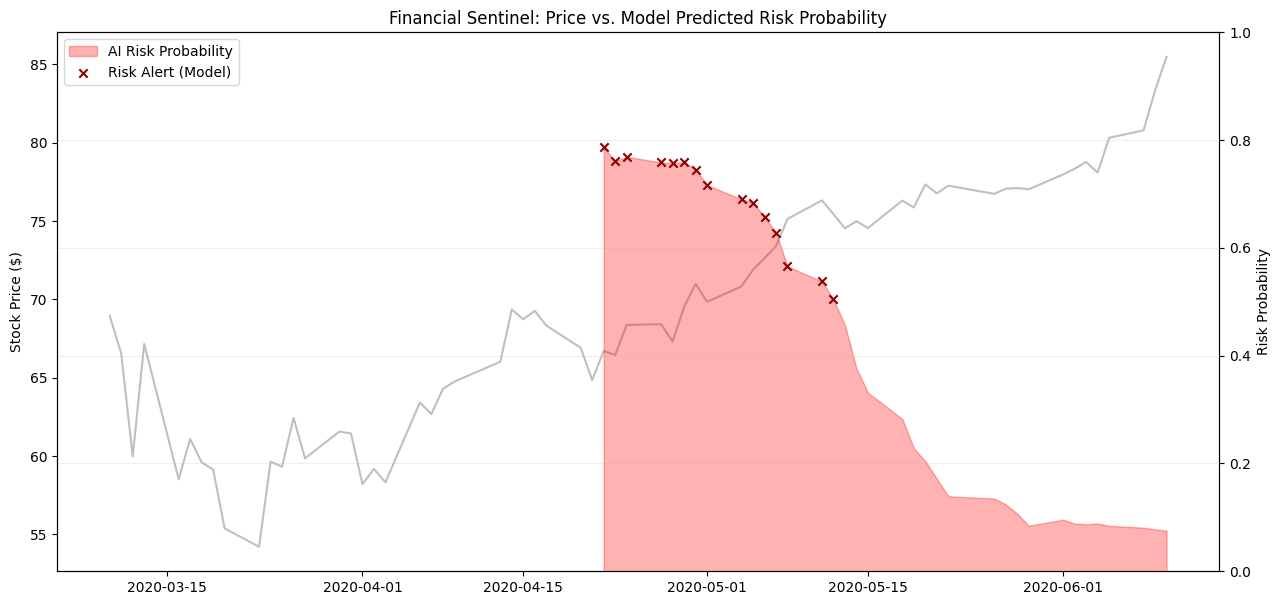

In [42]:
def plot_risk_overlay(df):
    plt.figure(figsize=(15, 7))

    # Plot Stock Price
    ax1 = plt.gca()
    ax1.plot(df['Date'], df['Close'], color='gray', alpha=0.5, label='AAPL Price')
    ax1.set_ylabel('Stock Price ($)')

    # Plot AI Risk Probability (using the model's prediction)
    ax2 = ax1.twinx()
    ax2.fill_between(df['Date'], 0, df['Predicted_Risk_Prob'],
                     color='red', alpha=0.3, label='AI Risk Probability')
    ax2.set_ylabel('Risk Probability')
    ax2.set_ylim(0, 1)

    # Highlight high-risk zones (based on model's prediction > 0.5)
    high_risk_days = df[df['Predicted_Risk_Prob'] > 0.5]
    ax2.scatter(high_risk_days['Date'], high_risk_days['Predicted_Risk_Prob'],
                color='darkred', marker='x', label='Risk Alert (Model)')

    plt.title('Financial Sentinel: Price vs. Model Predicted Risk Probability')
    plt.legend(loc='upper left')
    plt.grid(True, alpha=0.2)
    plt.show()

# Run this using your final_real_df
plot_risk_overlay(final_real_df)

### Fixing Class Imbalance with SMOTE

In [37]:
# Install imblearn for SMOTE
!pip install imblearn -q
print("Imblearn installed.")

Imblearn installed.


In [38]:
from imblearn.over_sampling import SMOTE

print("Applying SMOTE to balance the dataset...")

# 1. Prepare data for SMOTE
# Features are Close, Volatility, Sentiment_Risk_Score
X = final_real_df[lstm_features + news_feature].values
# Target is Target_Label
y = final_real_df[target_col].values

# Ensure y is suitable for SMOTE (labels must be integers)
y = y.astype(int)

# 2. Apply SMOTE
sm = SMOTE(random_state=42)
X_res, y_res = sm.fit_resample(X, y)

# 3. Combine resampled features and target into a new balanced DataFrame
# We need to construct a new data_matrix that includes the resampled data
balanced_data_matrix = np.hstack((X_res, y_res.reshape(-1, 1)))

print(f"Original target distribution: {np.bincount(y)}")
print(f"Resampled target distribution: {np.bincount(y_res)}")
print("Dataset balanced using SMOTE.")

Applying SMOTE to balance the dataset...
Original target distribution: [18 47]
Resampled target distribution: [47 47]
Dataset balanced using SMOTE.


### Retraining Model on Balanced Data

Starting Retraining on SMOTE-Balanced Data...
Epoch [10/50], Loss: 0.6053, Accuracy: 70.31%
Epoch [20/50], Loss: 0.5814, Accuracy: 70.31%
Epoch [30/50], Loss: 0.4268, Accuracy: 85.94%
Epoch [40/50], Loss: 0.4178, Accuracy: 78.12%
Epoch [50/50], Loss: 0.4196, Accuracy: 79.69%
Retraining on Balanced Data Complete!


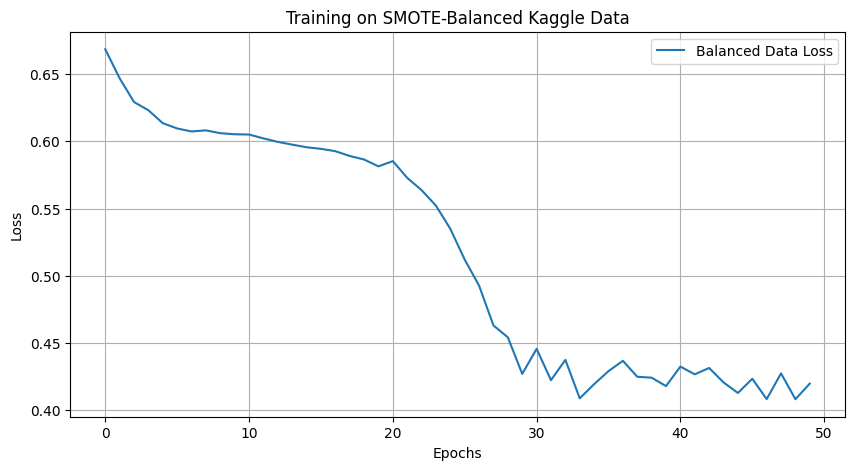

In [39]:
# Re-create Data Loaders with the balanced_data_matrix
balanced_dataset = FinancialDataset(balanced_data_matrix, seq_len=SEQ_LEN)
balanced_train_loader = DataLoader(balanced_dataset, batch_size=16, shuffle=True)

# Re-initialize Model, Loss, and Optimizer (important for a fresh start)
model = VolatilitySentinel(lstm_input_size=2, hidden_size=64, num_classes=2)
model.to(device)

# Recalculate weights based on the new, balanced dataset target distribution
num_safe_balanced = (y_res == 0).sum()
num_risky_balanced = (y_res == 1).sum()

# If we used SMOTE, the counts for 0 and 1 should be the same, so weights should be 1.0
# But we calculate dynamically for robustness
risk_weight_balanced = num_safe_balanced / num_risky_balanced if num_risky_balanced > 0 else 1.0
class_weights_balanced = torch.tensor([1.0, float(risk_weight_balanced)], dtype=torch.float).to(device)
criterion = nn.CrossEntropyLoss(weight=class_weights_balanced) # Use balanced weights
optimizer = optim.Adam(model.parameters(), lr=0.001)

EPOCHS = 50 # Retrain for a similar number of epochs
loss_history_balanced = []

print("Starting Retraining on SMOTE-Balanced Data...")
model.train()

for epoch in range(EPOCHS):
    epoch_loss = 0
    correct = 0
    total = 0

    for lstm_x, news_x, labels in balanced_train_loader:
        lstm_x, news_x, labels = lstm_x.to(device), news_x.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(lstm_x, news_x)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    avg_loss = epoch_loss / len(balanced_train_loader)
    loss_history_balanced.append(avg_loss)

    if (epoch+1) % 10 == 0:
        acc = 100 * correct / total
        print(f"Epoch [{epoch+1}/{EPOCHS}], Loss: {avg_loss:.4f}, Accuracy: {acc:.2f}%")

print("Retraining on Balanced Data Complete!")

# Plot the new learning curve
plt.figure(figsize=(10, 5))
plt.plot(loss_history_balanced, label='Balanced Data Loss')
plt.title('Training on SMOTE-Balanced Kaggle Data')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

### Re-evaluating Model Performance


--- Model Performance Report ---
              precision    recall  f1-score   support

      Stable       0.84      0.91      0.87        45
   High Risk       0.73      0.58      0.65        19

    accuracy                           0.81        64
   macro avg       0.79      0.75      0.76        64
weighted avg       0.81      0.81      0.81        64



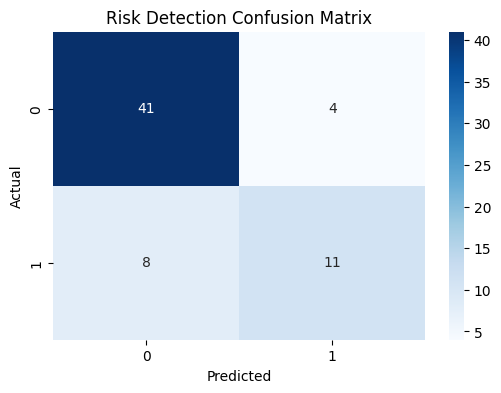

In [40]:
# Evaluate the model on the balanced data (using the balanced_train_loader for this demo)
# In a real scenario, you would want a separate validation/test set that was NOT oversampled.
evaluate_model(model, balanced_train_loader)

In [41]:
import torch
from torch.utils.data import DataLoader
import numpy as np

# Ensure model is on the correct device and in evaluation mode
model.to(device)
model.eval()

# Re-derive real_data_matrix from the (now correctly indexed) final_real_df
lstm_features = ['Close', 'Volatility']
news_feature = ['Sentiment_Risk_Score']
target_col = 'Target_Label'
real_data_matrix = final_real_df[lstm_features + news_feature + [target_col]].values

# Re-create the dataset and DataLoader without shuffling for predictable order
# This ensures that the predictions align correctly with final_real_df
predict_dataset = FinancialDataset(real_data_matrix, seq_len=SEQ_LEN)
predict_loader = DataLoader(predict_dataset, batch_size=1, shuffle=False) # Batch size 1 for easy mapping

predicted_risk_probabilities_model = []
with torch.no_grad():
    for lstm_x, news_x, labels in predict_loader:
        lstm_x, news_x = lstm_x.to(device), news_x.to(device)
        outputs = model(lstm_x, news_x)
        probabilities = torch.nn.functional.softmax(outputs, dim=1)
        predicted_risk_probabilities_model.append(probabilities[0][1].item())

# Create a new column in final_real_df for the model's predicted risk probabilities
# The first SEQ_LEN days do not have predictions, as they are used as history.
# We will fill these with NaN, then append the actual predictions.
final_real_df['Predicted_Risk_Prob'] = np.nan # Initialize with NaN

# The predictions correspond to days from index SEQ_LEN onwards in final_real_df
# Use iloc for positional assignment
expected_predictions_length = len(final_real_df) - SEQ_LEN
if expected_predictions_length == len(predicted_risk_probabilities_model):
    final_real_df.iloc[SEQ_LEN:, final_real_df.columns.get_loc('Predicted_Risk_Prob')] = predicted_risk_probabilities_model
else:
    print(f"Warning: Mismatch in lengths. DataFrame has {expected_predictions_length} prediction slots, but model generated {len(predicted_risk_probabilities_model)} predictions.")
    # Handle the mismatch more gracefully if it occurs, e.g., by raising an error or padding/truncating
    raise ValueError("Length mismatch after recalculating data matrix. Check data consistency.")

print("Model's predicted risk probabilities added to final_real_df.")

Model's predicted risk probabilities added to final_real_df.
